<a href="https://colab.research.google.com/github/AliMostafa12345/Data-Science-Portfolio/blob/main/Project%202/regression_project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

In [ ]:
import pandas as pd

df = pd.read_csv("DS Project 2, used_cars folder/used_cars.csv")

df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [ ]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [ ]:
# ==============================
# Data Understanding
# ==============================

# Showing the first 5 rows of the dataset
df.head()


# Checking the number of rows and columns
print("Dataset Shape:")
print(df.shape)


# Checking column names
print("\nColumn Names:")
print(df.columns)


# Checking data types and missing values
print("\nDataset Information:")
df.info()


# Getting basic statistical information
print("\nStatistical Summary:")
df.describe()


# Checking missing values in each column
print("\nMissing Values:")
missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_data = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_data[missing_data["Missing Values"] > 0]


# Checking for duplicate rows
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())


# Checking how many unique values each column has
print("\nUnique Values in Each Column:")

for column in df.columns:
    print(column, ":", df[column].nunique())

Dataset Shape:
(4009, 12)

Column Names:
Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB

Stati

In [ ]:
# ==============================
# Data Cleaning
# ==============================

# Creating a copy of the dataset before cleaning
df_clean = df.copy()


# Removing symbols from price and converting it to numeric
df_clean["price"] = (
    df_clean["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)


# Removing symbols from mileage and converting it to numeric
df_clean["milage"] = (
    df_clean["milage"]
    .str.replace(",", "", regex=False)
    .str.replace(" mi.", "", regex=False)
    .astype(float)
)


# Checking the converted columns
print(df_clean[["price", "milage"]].head())


# Checking missing values before handling them
print("\nMissing values before handling:")
print(df_clean.isnull().sum())


# Filling categorical missing values with the most common value
categorical_columns = df_clean.select_dtypes(include="object").columns

for column in categorical_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].mode()[0])


# Checking missing values after handling them
print("\nMissing values after handling:")
print(df_clean.isnull().sum())


# Checking data types after cleaning
print("\nData types after cleaning:")
df_clean.info()

     price   milage
0  10300.0  51000.0
1  38005.0  34742.0
2  54598.0  22372.0
3  15500.0  88900.0
4  34999.0   9835.0

Missing values before handling:
brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

Missing values after handling:
brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64

Data types after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         4009 non-null   object 
 1   model         4009 non-null   object 
 2   model_year    4009 no

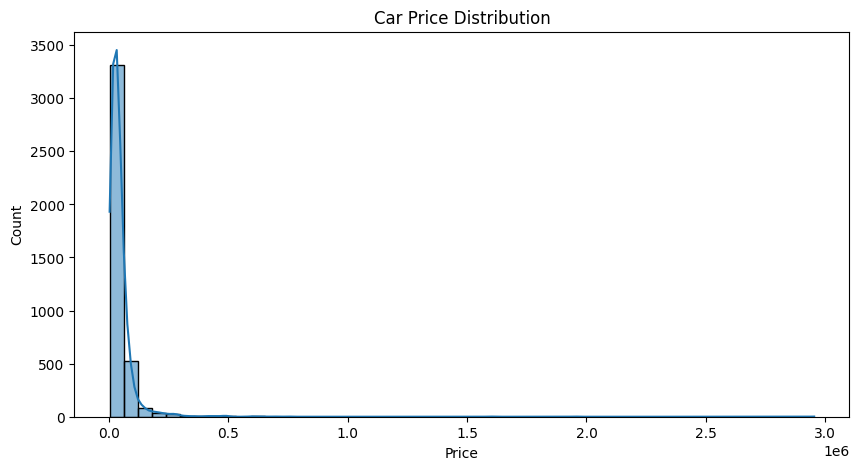

Price Statistics:
count    4.009000e+03
mean     4.455319e+04
std      7.871064e+04
min      2.000000e+03
25%      1.720000e+04
50%      3.100000e+04
75%      4.999000e+04
max      2.954083e+06
Name: price, dtype: float64


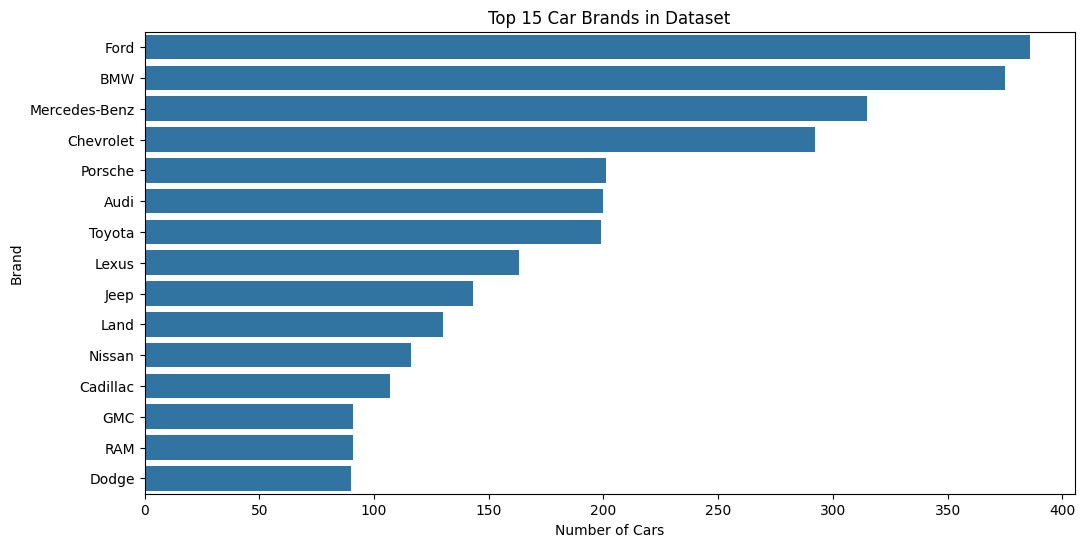

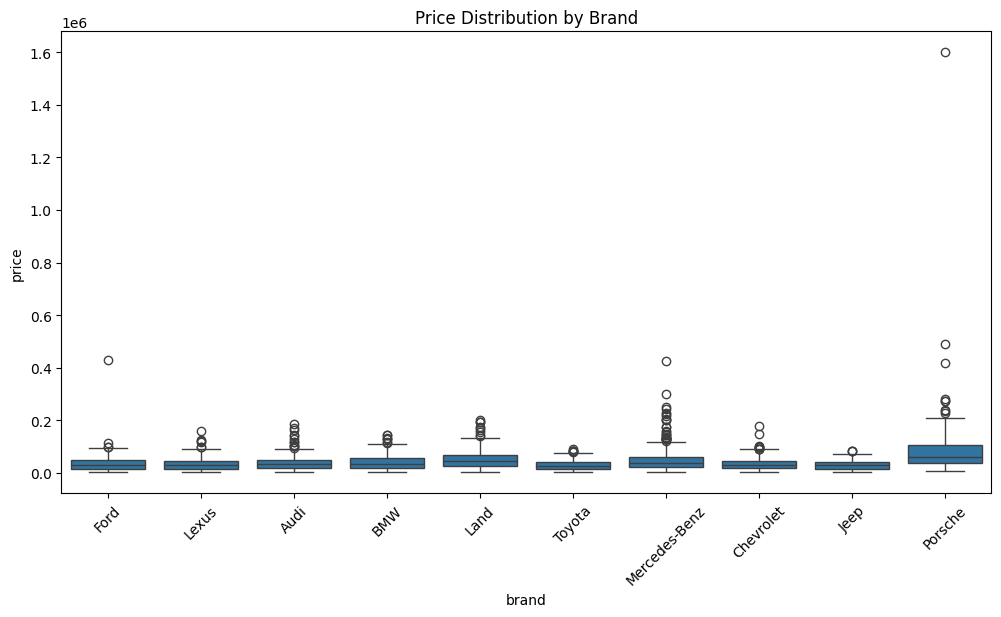

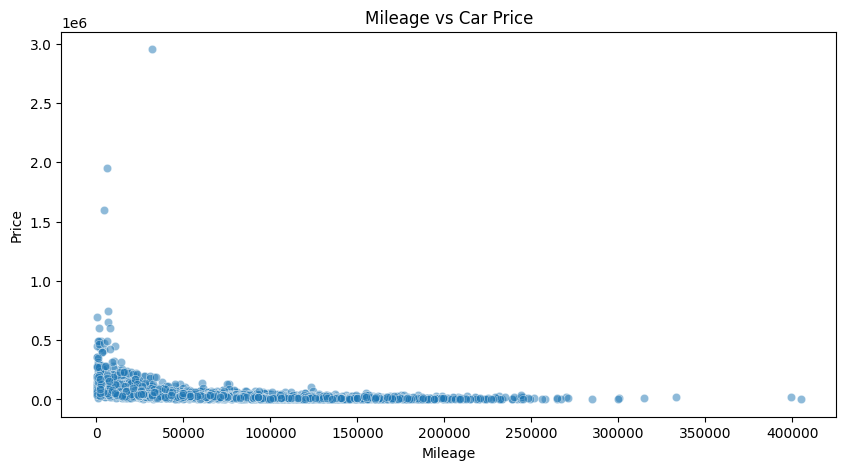

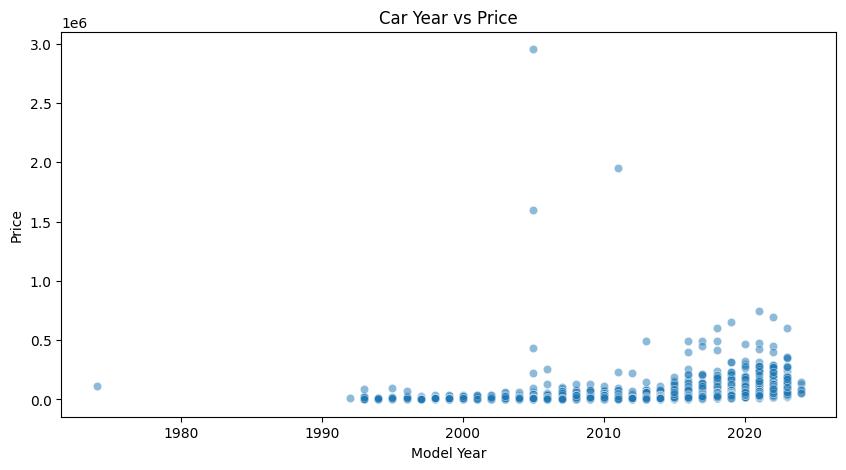

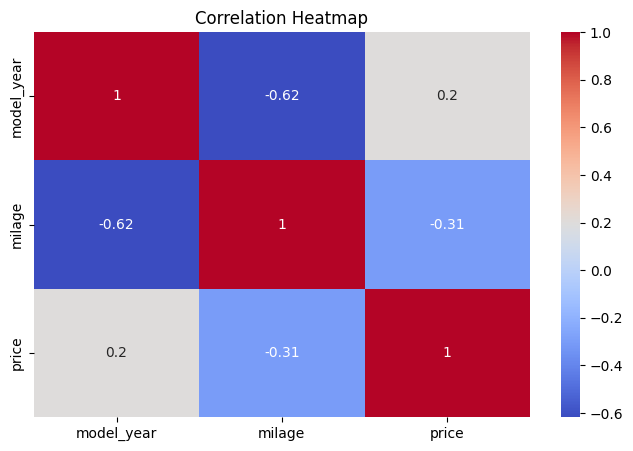

In [ ]:
# ==============================
# Exploratory Data Analysis
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns


# Price distribution
plt.figure(figsize=(10,5))
sns.histplot(df_clean["price"], bins=50, kde=True)

plt.title("Car Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()



# Checking price statistics
print("Price Statistics:")
print(df_clean["price"].describe())



# Top car brands by number of listings
plt.figure(figsize=(12,6))

brand_counts = df_clean["brand"].value_counts().head(15)

sns.barplot(
    x=brand_counts.values,
    y=brand_counts.index
)

plt.title("Top 15 Car Brands in Dataset")
plt.xlabel("Number of Cars")
plt.ylabel("Brand")
plt.show()



# Price by car brand (top 10 brands)
top_brands = df_clean["brand"].value_counts().head(10).index

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_clean[df_clean["brand"].isin(top_brands)],
    x="brand",
    y="price"
)

plt.title("Price Distribution by Brand")
plt.xticks(rotation=45)
plt.show()



# Relationship between mileage and price
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df_clean,
    x="milage",
    y="price",
    alpha=0.5
)

plt.title("Mileage vs Car Price")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.show()



# Relationship between car year and price
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df_clean,
    x="model_year",
    y="price",
    alpha=0.5
)

plt.title("Car Year vs Price")
plt.xlabel("Model Year")
plt.ylabel("Price")
plt.show()



# Correlation heatmap for numeric columns

plt.figure(figsize=(8,5))

numeric_columns = df_clean.select_dtypes(include=["int64","float64"])

sns.heatmap(
    numeric_columns.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

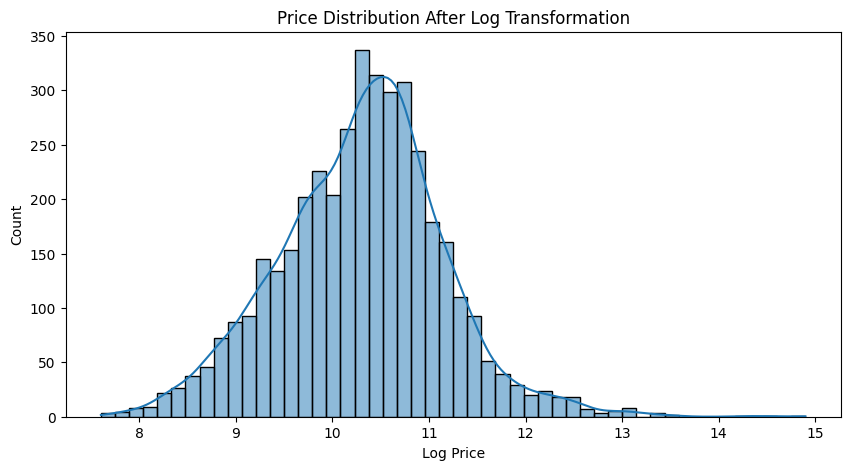

count    4009.000000
mean       10.302401
std         0.850058
min         7.601402
25%         9.752723
50%        10.341775
75%        10.819598
max        14.898699
Name: log_price, dtype: float64


In [ ]:
# Applying log transformation to reduce price skewness

df_clean["log_price"] = np.log1p(df_clean["price"])


# Checking the new distribution

plt.figure(figsize=(10,5))

sns.histplot(
    df_clean["log_price"],
    bins=50,
    kde=True
)

plt.title("Price Distribution After Log Transformation")
plt.xlabel("Log Price")
plt.show()


# Checking statistics after transformation

print(df_clean["log_price"].describe())

In [ ]:
# ==============================
# Feature Engineering
# ==============================

# Create a new dataframe for modeling
df_model = df_clean.copy()


# Check engine examples
print(df_model["engine"].head())


# Extract engine displacement number
df_model["engine_size"] = (
    df_model["engine"]
    .str.extract(r"(\d+\.\d+|\d+)")
    .astype(float)
)


# Check extracted values
print(df_model[["engine", "engine_size"]].head())


# Drop columns that are difficult to use directly

df_model.drop(
    columns=["engine", "price"],
    inplace=True
)


# Keep log_price as target
df_model.head()

0    300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...
1                                 3.8L V6 24V GDI DOHC
2                                       3.5 Liter DOHC
3    354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...
4                           2.0L I4 16V GDI DOHC Turbo
Name: engine, dtype: object
                                              engine  engine_size
0  300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...        300.0
1                               3.8L V6 24V GDI DOHC          3.8
2                                     3.5 Liter DOHC          3.5
3  354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...        354.0
4                         2.0L I4 16V GDI DOHC Turbo          2.0


,brand,model,model_year,milage,fuel_type,transmission,ext_col,int_col,accident,clean_title,log_price,engine_size
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,9.239996,300.0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,10.545499,3.8
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,Automatic,Blue,Black,None reported,Yes,10.907771,3.5
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,7-Speed A/T,Black,Black,None reported,Yes,9.648660,354.0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,8-Speed Automatic,Glacier White Metallic,Black,None reported,Yes,10.463103,2.0


In [ ]:
# ==============================
# Fix Engine Feature
# ==============================

# Extract engine size in liters (number before L)
df_model["engine_size"] = (
    df_clean["engine"]
    .str.extract(r"(\d+\.\d+)\s*L")
    .astype(float)
)


# Check results
df_model[["engine_size"]].head(10)

,engine_size
0,3.7
1,3.8
2,3.5
3,3.5
4,2.0
5,2.4
6,2.0
7,4.4
8,3.5
9,NaN


In [ ]:
# Remove rows where engine size was not extracted
df_model = df_model.dropna(subset=["engine_size"])


# Check final shape
df_model.shape

(3773, 12)

In [ ]:
# ==============================
# Encoding Categorical Features
# ==============================

from sklearn.preprocessing import LabelEncoder


# Create a copy for encoding
df_encoded = df_model.copy()


# Remove high-cardinality columns
# Too many unique values can hurt the model
df_encoded.drop(
    columns=["model"],
    inplace=True
)


# Apply Label Encoding to categorical columns

categorical_columns = df_encoded.select_dtypes(include="object").columns

encoder = LabelEncoder()

for column in categorical_columns:
    df_encoded[column] = encoder.fit_transform(df_encoded[column])


# Check final dataset
print(df_encoded.head())


# Check data types
print("\nData Types:")
print(df_encoded.dtypes)


# Check shape
print("\nDataset Shape:")
print(df_encoded.shape)

   brand  model_year   milage  fuel_type  transmission  ext_col  int_col  \
0     14        2013  51000.0          1            14       28       11   
1     19        2021  34742.0          2            29      171       65   
2     27        2022  22372.0          2            36       37       11   
3     20        2015  88900.0          3            21       28       11   
4      3        2021   9835.0          2            29      110       11   

   accident  clean_title  log_price  engine_size  
0         0            0   9.239996          3.7  
1         0            0  10.545499          3.8  
2         1            0  10.907771          3.5  
3         1            0   9.648660          3.5  
4         1            0  10.463103          2.0  

Data Types:
brand             int64
model_year        int64
milage          float64
fuel_type         int64
transmission      int64
ext_col           int64
int_col           int64
accident          int64
clean_title       int64
log_pric

In [ ]:
# ==============================
# Splitting Data
# ==============================

from sklearn.model_selection import train_test_split


# Separate features and target

X = df_encoded.drop("log_price", axis=1)

y = df_encoded["log_price"]


# Split dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Check the sizes

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3018, 10)
Testing data: (755, 10)


In [ ]:
# ==============================
# Model Training
# ==============================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ------------------------------
# Linear Regression Model
# ------------------------------

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)


# Predictions

linear_predictions = linear_model.predict(X_test)



# ------------------------------
# Random Forest Model
# ------------------------------

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)


# Predictions

rf_predictions = rf_model.predict(X_test)



# ------------------------------
# Model Evaluation Function
# ------------------------------

def evaluate_model(y_true, predictions, model_name):

    mae = mean_absolute_error(y_true, predictions)
    rmse = np.sqrt(mean_squared_error(y_true, predictions))
    r2 = r2_score(y_true, predictions)

    print(model_name)
    print("--------------------")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print()


# Evaluate models

evaluate_model(
    y_test,
    linear_predictions,
    "Linear Regression"
)


evaluate_model(
    y_test,
    rf_predictions,
    "Random Forest"
)

Linear Regression
--------------------
MAE: 0.3470590021055784
RMSE: 0.4811852101368831
R2 Score: 0.6873235244828941

Random Forest
--------------------
MAE: 0.24910969957136286
RMSE: 0.3566680580340013
R2 Score: 0.8282095165969878



In [ ]:
# ==============================
# XGBoost Model
# ==============================

from xgboost import XGBRegressor


# Create model

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)


# Train model

xgb_model.fit(
    X_train,
    y_train
)


# Predictions

xgb_predictions = xgb_model.predict(X_test)



# Evaluate XGBoost

evaluate_model(
    y_test,
    xgb_predictions,
    "XGBoost"
)

XGBoost
--------------------
MAE: 0.22258511977054096
RMSE: 0.3225916356647666
R2 Score: 0.859467467519423



In [ ]:
# ==============================
# Model Comparison
# ==============================

model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "R2 Score": [
        r2_score(y_test, linear_predictions),
        r2_score(y_test, rf_predictions),
        r2_score(y_test, xgb_predictions)
    ],
    "MAE": [
        mean_absolute_error(y_test, linear_predictions),
        mean_absolute_error(y_test, rf_predictions),
        mean_absolute_error(y_test, xgb_predictions)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_predictions)),
        np.sqrt(mean_squared_error(y_test, rf_predictions)),
        np.sqrt(mean_squared_error(y_test, xgb_predictions))
    ]
})


# Sort by best R2 score

model_results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,R2 Score,MAE,RMSE
2,XGBoost,0.859467,0.222585,0.322592
1,Random Forest,0.828210,0.249110,0.356668
0,Linear Regression,0.687324,0.347059,0.481185


In [ ]:
# ==============================
# Feature Importance
# ==============================

# Getting feature importance from XGBoost

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})


# Sort features by importance

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


# Display feature importance

feature_importance

,Feature,Importance
2,milage,0.413316
9,engine_size,0.188945
1,model_year,0.174829
0,brand,0.060404
3,fuel_type,0.045539
4,transmission,0.039143
7,accident,0.031649
6,int_col,0.030128
5,ext_col,0.016047
8,clean_title,0.000000


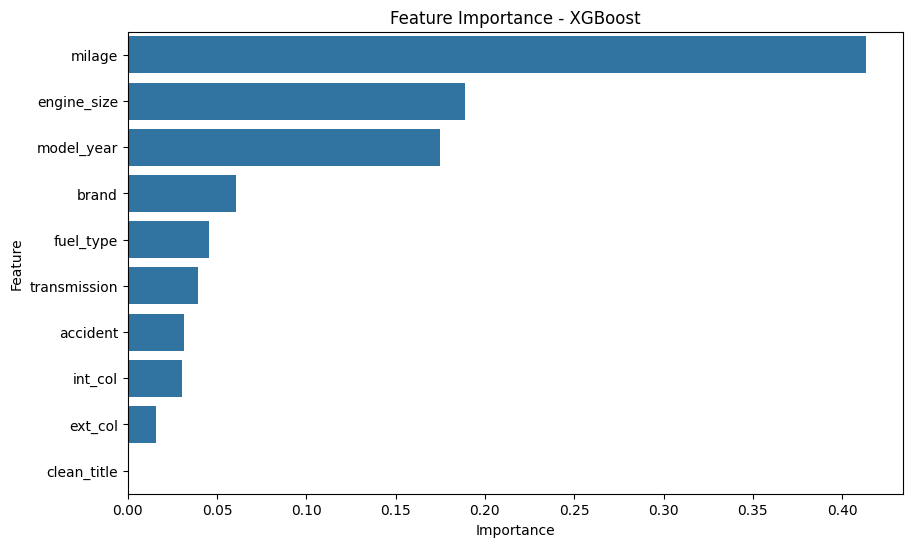

In [ ]:
# Plot feature importance

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - XGBoost")
plt.show()

In [ ]:
# ==============================
# XGBoost Hyperparameter Tuning
# ==============================

from xgboost import XGBRegressor


# Improved XGBoost model

xgb_tuned = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


# Train model

xgb_tuned.fit(
    X_train,
    y_train
)


# Predictions

tuned_predictions = xgb_tuned.predict(X_test)


# Evaluate tuned model

evaluate_model(
    y_test,
    tuned_predictions,
    "Tuned XGBoost"
)

Tuned XGBoost
--------------------
MAE: 0.2145106845718054
RMSE: 0.3103409565151172
R2 Score: 0.869938470732923



In [ ]:
# ==============================
# Convert Predictions Back to Price
# ==============================

# Convert log predictions back to original price

actual_prices = np.expm1(y_test)

predicted_prices = np.expm1(tuned_predictions)


# Create comparison dataframe

price_comparison = pd.DataFrame({
    "Actual Price": actual_prices,
    "Predicted Price": predicted_prices
})


# Show sample predictions

price_comparison.head(10)

,Actual Price,Predicted Price
99,4995.0,6394.217285
4005,53900.0,69020.335938
2808,17500.0,17928.638672
1427,47500.0,45939.117188
380,71000.0,55418.488281
2355,18000.0,25752.806641
2522,28500.0,28486.841797
1146,17000.0,13723.507812
2721,25000.0,23322.943359
2820,46999.0,47785.023438


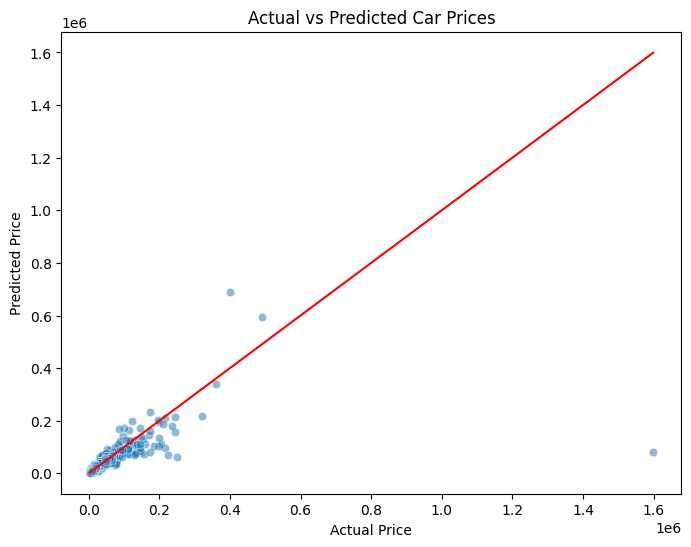

In [ ]:
# ==============================
# Actual vs Predicted Prices
# ==============================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=actual_prices,
    y=predicted_prices,
    alpha=0.5
)


# Perfect prediction line

plt.plot(
    [actual_prices.min(), actual_prices.max()],
    [actual_prices.min(), actual_prices.max()],
    color="red"
)


plt.title("Actual vs Predicted Car Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.show()

In [ ]:
# ==============================
# Prediction Error Analysis
# ==============================

# Calculate errors

price_comparison["Error"] = (
    price_comparison["Actual Price"] - price_comparison["Predicted Price"]
)


# Absolute error

price_comparison["Absolute Error"] = (
    abs(price_comparison["Error"])
)


# Show biggest mistakes

largest_errors = price_comparison.sort_values(
    by="Absolute Error",
    ascending=False
)


largest_errors.head(10)

,Actual Price,Predicted Price,Error,Absolute Error
3046,1599000.0,82575.531250,1.516424e+06,1.516424e+06
1811,399900.0,688395.687500,-2.884957e+05,2.884957e+05
16,250000.0,61735.882812,1.882641e+05,1.882641e+05
3057,226000.0,68868.710938,1.571313e+05,1.571313e+05
3537,215000.0,95397.343750,1.196027e+05,1.196027e+05
2971,319900.0,218434.000000,1.014660e+05,1.014660e+05
3655,491836.0,592702.750000,-1.008668e+05,1.008668e+05
1848,200000.0,103164.062500,9.683594e+04,9.683594e+04
785,175000.0,80144.062500,9.485594e+04,9.485594e+04
2839,204900.0,113180.640625,9.171936e+04,9.171936e+04


In [ ]:
# ==============================
# Saving Final Model
# ==============================

import joblib


# Save the trained model

joblib.dump(
    xgb_tuned,
    "used_car_price_model.pkl"
)


print("Model saved successfully!")

Model saved successfully!


In [ ]:
import os

os.listdir()

['.config',
 'DS Project 2, used_cars folder',
 'used_car_price_model.pkl',
 'sample_data']

In [ ]:
# Conclusion

# In this project, a machine learning regression model was developed to predict used car prices.

# The dataset was cleaned by handling missing values, converting incorrect data types, and performing feature engineering. The price variable was log-transformed to reduce the effect of extreme values.

# Different regression models were tested:
# - Linear Regression
# - Random Forest Regressor
# - XGBoost Regressor

# Among these models, the tuned XGBoost model achieved the best performance with an R² score of approximately 0.87.

# The model was able to capture important relationships between vehicle characteristics and prices, such as mileage, model year, brand, and engine size.

# However, the model had difficulty predicting extremely expensive luxury vehicles due to the limited number of high-value examples in the dataset.

# Overall, this project demonstrates an end-to-end regression workflow, including data preprocessing, exploratory analysis, model development, evaluation, and saving the final trained model.